# Time Series Analysis: iSAX

iSAX is a time series representation that allows efficient indexing. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, zscore

Let's again generate some data for scalability, as an index's strength lies in handling massive amounts of data:

In [2]:
def generate_indexing_data(num_series, length, normalize=True):
    # 1. Generate random Gaussian steps
    steps = np.random.normal(loc=0.0, scale=1.0, size=(num_series, length))
    
    # 2. Cumulative sum connects the steps into a continuous random walk
    random_walks = np.cumsum(steps, axis=1)
    
    return zscore(random_walks, axis=1)

ts_data = generate_indexing_data(num_series=100000, length=256)

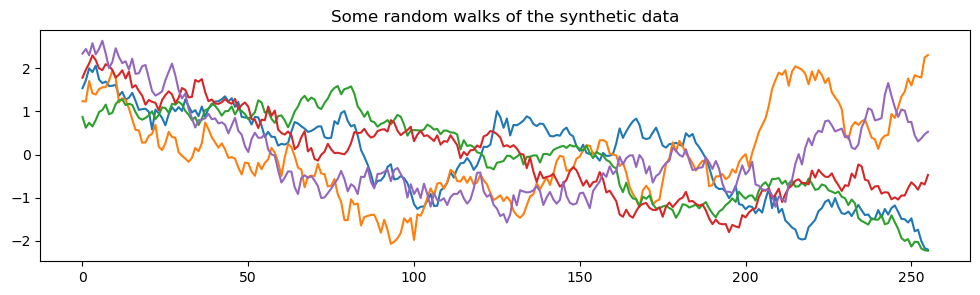

In [3]:
plt.figure(figsize=(12, 3))
plt.title("Some random walks of the synthetic data")
plt.plot(ts_data[:5, :].T)
plt.show()

## 1. iSAX Representation

Indexable Symbolic Aggregation Approximation (iSAX) builds on top of PAA and is comparable to regular SAX. Recall that PAA (Piecewise Aggregate Approximation) reduces dimensionality by averaging segments of the time series, while SAX discretizes those averages into a symbolic alphabet. iSAX makes this alphabet searchable by using a binary hierarchy.

So, a z-normalized time series gets split into segments and their average is extracted (PAA). Based on the cardinality assigned for each letter, the PAA value fits into a probability bin corresponding to a binary number. This binary number then represents the segment of the time series. 

The iSAX of the time series is the collection of binary symbols for the segments.

--------------------------

In order to collect all functions related to the core iSAX representation, we built an Encoder class. This class holds the parameters of iSAX as well as a breakpoint table for fast lookups. It provides iSAX, PAA, finding probability bin bounds for a given value and building the breakpoint table given a maximum cardinality.

**Let's focus on the iSAX implementation:**
<br>
At first, iSAX finds the PAA representation of the time series. We assume normalized data as input. The PAA has as many segments as the length of the iSAX word.

For each PAA value, iSAX needs the cardinality of the respective symbol which has to be provided along with the time series. It then looks up the corresponding binary symbol of the given cardinality for the PAA value. To do this look up efficiently, a breakpoint table can be calculated up front.

In order to make the iSAX available as a key for indexing, python can use a tuple of strings. Accordingly, the tuple is the iSAX where each position inside the tuple is a string of a binary symbol for the "letters".

In [4]:
class Encoder():
    def __init__(self, word_length, max_cardinality=256):
        self.n_segments = word_length
        self.max_cardinality = max_cardinality
        
        # Pre-compute the boundaries on initialization
        self.breakpoint_table = self._build_breakpoint_table()

    def _build_breakpoint_table(self):
        table = {}
        c = 2
        
        # iSAX cardinalities iteratively double (2, 4, 8, 16, 32...)
        while c <= self.max_cardinality:
            # We need c-1 breakpoints to divide the space into c bins
            percentiles = np.arange(1, c) / c
            
            # norm.ppf finds the exact Z-score boundaries for those percentiles
            table[c] = norm.ppf(percentiles)
            
            c *= 2
            
        return table
    
    def get_bounds(self, binary_symbol, cardinality):
        # Fetch the pre-computed array of boundaries for this cardinality
        breakpoints = self.breakpoint_table[cardinality]
        
        # Convert the binary string (e.g., '10') back to a base-10 integer index
        symbol_index = int(binary_symbol, 2)
        
        # Scenario 1: The bottom bin (extends to negative infinity)
        if symbol_index == 0:
            beta_L = -np.inf
            beta_U = breakpoints[0]
            
        # Scenario 2: The top bin (extends to positive infinity)
        elif symbol_index == cardinality - 1:
            beta_L = breakpoints[-1]
            beta_U = np.inf
            
        # Scenario 3: Caught between two boundaries
        else:
            beta_L = breakpoints[symbol_index - 1]
            beta_U = breakpoints[symbol_index]
            
        return beta_L, beta_U

    def paa(self, ts):
        # split_segments creates a list of sub-arrays. 
        split_segments = np.array_split(ts, self.n_segments)

        # Calculate the mean for each segment and wrap it back into a numpy array
        ts_paa = np.array([np.mean(seg) for seg in split_segments])
        
        return ts_paa
    
    def iSAX(self, ts, cardinalities):        
        # 1. Compute PAA using the class method
        ts_paa = self.paa(ts) # Assume normalized data

        isax_symbols = []
        
        # 2. Convert PAA values to binary symbols using the pre-computed table
        for i in range(self.n_segments):
            c = cardinalities[i]
            breakpoints = self.breakpoint_table[c] 
            
            paa_value = ts_paa[i]
            
            # np.searchsorted efficiently finds which bin the value falls into
            symbol_index = np.searchsorted(breakpoints, paa_value)
            
            # Convert the integer index to a zero-padded binary string
            num_bits = int(np.log2(c))
            binary_symbol = format(symbol_index, f'0{num_bits}b')
            
            isax_symbols.append(binary_symbol)

        # 3: Return as a tuple so it can be hashed as a dictionary key in the Index
        return tuple(isax_symbols)

The lecture also shows two additional functionalities of iSAX: Comparing two different cardinality iSAX words by downgrading and promoting cardinalities of the iSAX.

To **downgrade** the cardinality of a word by some steps $n$, simply the last $n$ values of each symbol within the word are removed.

To **promote** the cardinality of a word to the same as a given goal iSAX word, it appends values to the word that keep the order between the iSAXs. For each symbol in the query, it follows these three rules:
1. Query symbol is prefix: Copy the rest from goal symbol
2. Query symbol is smaller: Append only ones.
3. Query symbol is larger: Append only zeros.

In [5]:
def downgrade_cardinality(query_isax, steps):
    # Safety check: If steps is 0, just return the original word!
    if steps == 0:
        return query_isax
        
    return tuple(symbol[:-steps] for symbol in query_isax)

def promote_cardinality(query_isax, goal_isax):
    promoted_isax = []
    
    for q_sym, g_sym in zip(query_isax, goal_isax):
        
        # Calculate how many bits we need to add
        diff = len(g_sym) - len(q_sym)
        
        if diff <= 0:
            promoted_isax.append(q_sym)
            continue
            
        # Isolate the prefix of the goal symbol that matches our current length
        prefix = g_sym[:len(q_sym)]
        
        # Rule 1: If it's a perfect prefix, the unknown bits match the goal bits
        if q_sym == prefix:
            promoted_isax.append(g_sym)
            
        # Rule 2: If it's lexicographically smaller, all unknown bits become 1
        elif q_sym < prefix:
            promoted_isax.append(q_sym + ('1' * diff))
            
        # Rule 3: If it's lexicographically larger, all unknown bits become 0
        else:
            promoted_isax.append(q_sym + ('0' * diff))
            
    return tuple(promoted_isax)

The following cell first shows the results of promoting and downgrading iSAX words.

The plot shows how a higher cardinality is resulting in a more differenced iSAX. 

High-resolution word (c=8): ('111', '100', '100', '011', '000')
True Low-resolution word (c=4): ('11', '10', '10', '01', '00')
Downgraded Low-resolution word (c=8 -> c=4): ('11', '10', '10', '01', '00') | Matches True? True

Target word (c=8):   ('001', '110', '011', '101', '111')
Promoted word (c=4 -> c=8): ('110', '101', '100', '011', '001')


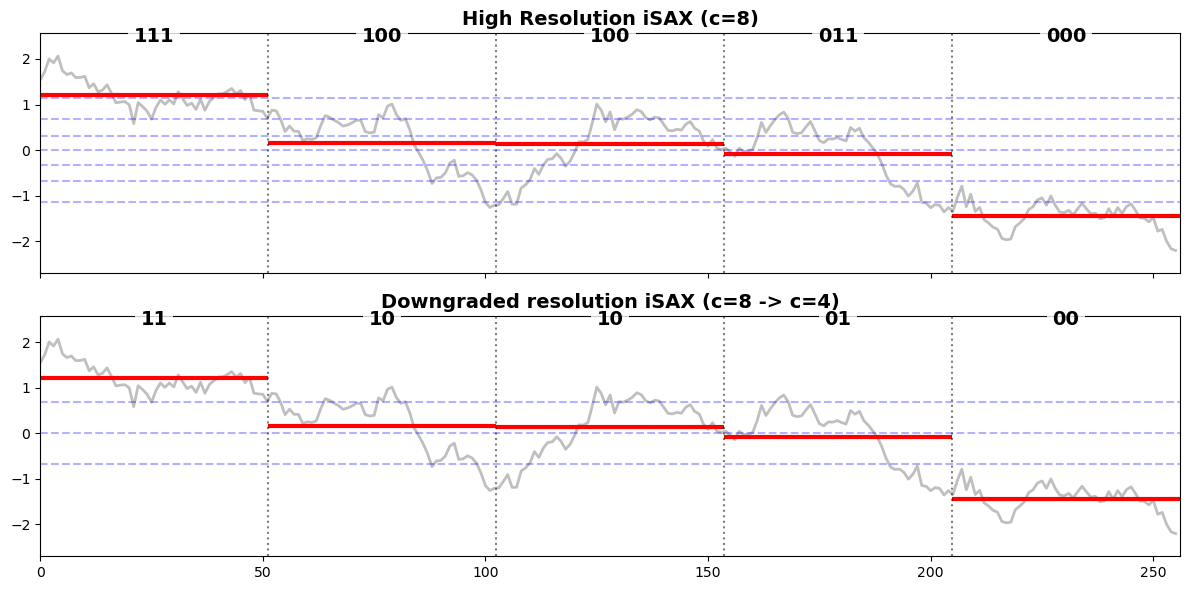

In [6]:
# Some iSAX parameters and words
word_length = 5
cardinalities_0 = [8] * word_length
cardinalites_1 = [4] * word_length

goal_iSAX = ('001', '110', '011', '101', '111')

encoder = Encoder(word_length, max_cardinality=8)
ts_paa = encoder.paa(ts_data[0])

# --- Process words and test logic ---
word_0 = encoder.iSAX(ts_data[0], cardinalities_0)
word_1_true = encoder.iSAX(ts_data[0], cardinalites_1)
word_0_downgraded = downgrade_cardinality(word_0, steps=1)

word_1_promoted = promote_cardinality(word_0_downgraded, goal_iSAX)

print(f"High-resolution word (c=8): {word_0}")
print(f"True Low-resolution word (c=4): {word_1_true}")
print(f"Downgraded Low-resolution word (c=8 -> c=4): {word_0_downgraded} | Matches True? {word_1_true == word_0_downgraded}\n")
print(f"Target word (c=8):   {goal_iSAX}")
print(f"Promoted word (c=4 -> c=8): {word_1_promoted}")

# --- Plotting ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.3)

x_edges = np.arange(0, len(ts_data[0]) + 1, len(ts_data[0]) / word_length)
panels = [(axes[0], 8, word_0, "High Resolution iSAX (c=8)"), (axes[1], 4, word_0_downgraded, "Downgraded resolution iSAX (c=8 -> c=4)")]

for ax, c, word, title in panels:
    ax.plot(ts_data[0], color='gray', alpha=0.5, lw=2, label="normalized time series")
    
    # Draw horizontal bounds
    for bp in encoder.breakpoint_table[c]:
        ax.axhline(bp, color='blue', ls='--', alpha=0.3, label="symbol bounds")

    # Draw PAA and text
    for i in range(word_length):
        start, end = x_edges[i], x_edges[i+1]
        ax.hlines(ts_paa[i], start, end, color='red', lw=3, label="PAA representation")
        ax.axvline(start, color='black', ls=':', alpha=0.5)
        ax.text((start + end) / 2, 2.5, word[i], fontsize=14, weight='bold', ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, ec='none'))

    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_ylim(min(ts_data[0]) - 0.5, max(ts_data[0]) + 0.5)
    ax.set_xlim(0, len(ts_data[0]))

plt.tight_layout()
plt.show()

## 2. iSAX Index

As the binary string of iSAX is indexible, we can build an iSAX index for time series. As with DSTree, we split the functionalities into a Node and Tree class.

The Node class is able to both manage inner and leaf nodes. However, the root node is not part of the iSAX node as it follows a different functionality - implementing it this way is solely a design decision.

The node fulfills several responsibilities:
- **Inserting** a time series if terminal or route along the tree if not
- **Splitting** itself when it is a full terminal node
- **Routing** to the correct child given a query time series
- Calculating the **mindist** lower bound to a query given its node's iSAX
- Finding the best **similarity** match to a query within the time series file if terminal

Inserting a time series to a terminal/leaf node is easy: Solely appending it to a file and if it overflows, splitting it into two children. <br> If it is an inner node, it calculates the time series iSAX and looks for the iSAX within its children. Either the time series is then passed to the according child or the child is created if the iSAX was not recorded before.

Splitting a node means finding the splitting dimension, i.e. the letter of the iSAX to refine. The original iSAX uses round robin, i.e. simply iterating through the letters, but the lecture uses a more sophisticated algorithm for finding the most promising letter. We implement the easier round robin here. It then increases the cardinality of that letter and calculates the iSAX for each time series within its file given the new cardinality. The time series are then distributed amongst the children given the respective iSAX words. <br>In this implementation, the PAA gets recalculated each split. If it is instead cached with the time series, the tree building is made more efficient.

Routing to a child calculates the iSAX given the nodes cardinalities for the query and routes accordingly. If no child exists for that iSAX, a heuristic is used: Routing to a child that matches on the current splitting dimension. We implement yet another heuristic to assure always returning a leaf node: Simply taking the first child - which makes this fallback basically random.

Calculating the mindist of a query to a node uses the distance of the PAA values of the query to the symbol breakpoints of the node's iSAX. It is more throroughly described below.

Similarity search within a leaf is simply a serial scan amongst its file.

In [7]:
import heapq

class iSaxNode():
    def __init__(self, isax_word, cardinalities, threshold, word_length, split_dim, encoder):
        # Constant parameters across nodes
        self.threshold = threshold
        self.word_length = word_length
        self.encoder = encoder

        # ISax of current node
        self.isax_word = isax_word
        self.cardinalities = cardinalities
        self.split_dim = split_dim

        # Traversal variables
        self.children_hash = {}
        self.file = []
        self.is_terminal = True # Node is always leaf when created

    @property
    def children(self):
        return list(self.children_hash.values())

    def is_full(self):
        return len(self.file) > self.threshold    

    def split_node(self):
        # 1: Calculate the elevated cardinalities for the children
        new_cardinalities = self.cardinalities.copy()
        new_cardinalities[self.split_dim] *= 2
        
        next_split_dim = (self.split_dim + 1) % self.word_length

        # 2: Redistribute existing time series to children
        for ts in self.file:
            ts_isax = self.encoder.iSAX(ts, cardinalities=new_cardinalities)
            
            if ts_isax not in self.children_hash:
                self.children_hash[ts_isax] = iSaxNode(
                    ts_isax, new_cardinalities, self.threshold, self.word_length, next_split_dim, self.encoder
                )
            self.children_hash[ts_isax].insert(ts)
            
        # 3: Update node to be internal
        self.is_terminal = False
        self.file = []

    def insert(self, ts):
        # 1: Determine node type
        if self.is_terminal:
            # 2.1: Items are always added to leafs
            self.file.append(ts)

            # 2.2: Split leaf if it overflows
            if self.is_full():
                self.split_node()
        else:
            # 3.1: Get time series isax for children when internal node
            target_cardinalities = self.cardinalities.copy()
            target_cardinalities[self.split_dim] *= 2
            
            ts_isax = self.encoder.iSAX(ts, cardinalities=target_cardinalities)

            # 3.2: Children are created lazily
            if ts_isax not in self.children_hash:
                next_split_dim = (self.split_dim + 1) % self.word_length
                self.children_hash[ts_isax] = iSaxNode(
                    ts_isax, target_cardinalities, self.threshold, self.word_length, next_split_dim, self.encoder
                )

            # 3.3: Route to child with respective isax
            self.children_hash[ts_isax].insert(ts)

    def calc_min_dist(self, query):
        best_ts = None
        best_dist = np.inf

        # Perform serial scan across node content
        for ts in self.file:
            # Euclidean distance
            dist = np.sqrt(np.sum((ts - query) ** 2))
            if dist < best_dist:
                best_dist = dist
                best_ts = ts

        return best_ts, best_dist
    
    def route_to_child(self, query):
        # 1. Predict the iSAX word using the elevated cardinalities
        target_cardinalities = self.cardinalities.copy()
        target_cardinalities[self.split_dim] *= 2
        query_iSAX = self.encoder.iSAX(query, target_cardinalities)

        # 2. Ideal Scenario: The exact hash path exists
        if query_iSAX in self.children_hash:
            return self.children_hash[query_iSAX]
        
        # 3. Fallback Heuristic 1: Match on the split dimension
        query_split_symbol = query_iSAX[self.split_dim]
        
        for child_word, child_node in self.children_hash.items():
            if child_word[self.split_dim] == query_split_symbol:
                return child_node
                
        # 4. Fallback Heuristic 2: Absolute failure, pick the first available child
        return list(self.children_hash.values())[0]
        
    def mindist_paa_isax(self, query):
        # 1: Calculate PAA of query time series
        query_normalized = (query - np.mean(query)) / (np.std(query) + 1e-8)
        query_paa = self.encoder.paa(query_normalized)

        # 2: Loop through every aggregated position
        dist_sq = 0.0
        for i in range(self.word_length):
            # 2.1: Fetch boundaries of the node's isax word
            symbol = self.isax_word[i]
            c = self.cardinalities[i]

            breakpoint_L, breakpoint_U = self.encoder.get_bounds(symbol, c)

            # 2.2: Calculate distance of paa to boundaries
            paa_val = query_paa[i]

            if breakpoint_L > paa_val:
                dist_sq += (breakpoint_L - paa_val) ** 2
            elif breakpoint_U < paa_val:
                dist_sq += (breakpoint_U - paa_val) ** 2

        # 3: Return normalized root of distance
        return np.sqrt((len(query) / self.word_length) * dist_sq)

In this implementation, the tree splits the **root** from the functionalities of the other nodes, as it is solely for routing to the first level.

The iSAX index in the original paper provides three core functionalities:
1. **Inserting** a time series into the tree
2. Perfoming an **approximate** similarity search
3. Perfoming an **exact** similarity search

For inserting, the iSAX checks all root entries and inserts it in the respective node, which is created lazily (only when actually containing an item). The inner nodes then route the time series recursively as described above.

For an approximate search, the function `iSaxNode.route_to_child()` is called recursively and the respective leaf node is returned. This leaf node does not necissarily have to contain the most similar time series to the query.

For an exact search, the result of the approximate search is taken as a best-so-far. It then traverses the tree and removes a node, if its iSAX to the query has a bigger distance. Thus, many nodes and their subtrees can be excluded. As each node that is within the iSAX distance is evaluated, one is guaranteed to find the most similar time series in the index.

The formula for the lower bound of an iSAX word to the PAA of the query is:

$$\text{MINDIST\_PAA\_iSAX}(T_{PAA}, S_{iSAX}) = \sqrt{ \frac{n}{w}} \sqrt{\sum_{i=1}^w 
\begin{cases} 
    (\beta_{Li} - T_{PAAi})^2 & \text{if } \beta_{Li} > T_{PAAi} \\
    (\beta_{Ui} - T_{PAAi})^2 & \text{if } \beta_{Ui} > T_{PAAi} \\
    0 & \text{otherwise}
\end{cases} }$$

with
- $\sqrt{ \frac{n}{w} } \sqrt{\dots}$ being a normalization factor given the query length $n$ and the iSAX word length $w$ and $\sqrt{\dots}$ resizing the squared distances
- $\sum_{i=1}^w$ aggregating the distance over each letter of the iSAX word
- $\beta_{Li}$ and $\beta_{Ui}$ marking the lower and upper breakpoints for the iSAX symbol at letter $i$. If the PAA of the query lies outside these breakpoints, the respective distance is used
- If the PAA matches the iSAX symbol - aka is within the breakpoints - no distance is contributed for that position

In [8]:
class iSaxIndex():
    def __init__(self, word_length=8, threshold=100, base_cardinality=4, max_cardinality=256):
        # Tree constants
        self.word_length = word_length
        self.threshold = threshold
        self.base_cardinalities = [base_cardinality] * word_length

        self.encoder = Encoder(word_length, max_cardinality)
        
        # Root node is stored as simple hash (only routes to children)
        self.root_hash = {}
        
    def insert(self, ts):
        # Calculate the base word
        base_word = self.encoder.iSAX(ts, self.base_cardinalities)
        
        # If this base word has never been seen, create a new terminal leaf for it
        if base_word not in self.root_hash:
            self.root_hash[base_word] = iSaxNode(
                isax_word=base_word,
                cardinalities=self.base_cardinalities,
                threshold=self.threshold, 
                word_length=self.word_length, 
                split_dim=0,
                encoder=self.encoder
            )
            
        # Push the data into the appropriate base-level node
        self.root_hash[base_word].insert(ts)
    
    def approximate_search(self, query):
        # 1: Start at the root dictionary
        base_word = self.encoder.iSAX(query, self.base_cardinalities)
        
        if base_word in self.root_hash:
            node = self.root_hash[base_word]
        else:
            # Fallback at the Root Level:
            node = list(self.root_hash.values())[0]

        # 2: Traverse down the tree
        while not node.is_terminal:
            node = node.route_to_child(query)

        # 3: Final node holds approximately similar items
        return node

    def exact_search(self, query):
        # 1: Get a best so far similarity through approximate search
        bsf_node = self.approximate_search(query)
        bsf_ts, bsf_dist = bsf_node.calc_min_dist(query)

        count = 0
        priority_queue = []

        # 2: Insert first nodes for evaluation
        for child in self.root_hash.values():
            child_lb = child.mindist_paa_isax(query)

            count += 1
            heapq.heappush(
                priority_queue,
                (child_lb, count, child)
            )

        # 3: Loop through candidates
        while priority_queue:
            current_lb, _, current_node = heapq.heappop(priority_queue)

            # Early stop: Best candidate has too high lower bound
            if current_lb >= bsf_dist:
                break
            
            if current_node.is_terminal:
                # 3.1: If node is leaf, check whether it holds more similar item
                current_ts, current_dist = current_node.calc_min_dist(query)

                if current_dist < bsf_dist:
                    bsf_dist = current_dist
                    bsf_ts = current_ts
            else:
                # 3.2: Traverse down the tree
                for child in current_node.children:
                    child_lb = child.mindist_paa_isax(query)
                  
                    count += 1
                    heapq.heappush(
                        priority_queue,
                        (child_lb, count, child)
                    )

        return bsf_ts, bsf_dist

## 3. Experiments

To showcase the split, we are building a very small iSAX index tree. Feel free to play with the parameters!

In [9]:
# Play with the showcasing parameters
tiny_n_elements = 10
tiny_word_length = 3
tiny_threshold = 2
tiny_cardinality = 2

def print_isax_tree(index):
    print("\n=== Tiny iSAX Tree Structure ===")

    if not index.root_hash:
        print("Empty.")
        return

    def traverse_node(node, path_word, depth):
        indent = "    " * depth
        branch = "└── " if depth > 0 else ""
        
        if node.is_terminal:
            print(f"{indent}{branch}[Leaf] Word: {path_word} | Cards: {node.cardinalities} | TS Count: {len(node.file)}")
        else:
            print(f"{indent}{branch}[Node] Word: {path_word} | Cards: {node.cardinalities} | Split Dim: {node.split_dim}")
            for child_word, child_node in node.children_hash.items():
                traverse_node(child_node, child_word, depth + 1)

    for base_word, base_node in index.root_hash.items():
        traverse_node(base_node, base_word, 0)

tiny_index = iSaxIndex(word_length=tiny_word_length, threshold=tiny_threshold, base_cardinality=tiny_cardinality)

print(f"Inserting {tiny_n_elements} time series into the tree...")
for i, ts in enumerate(ts_data[:tiny_n_elements, :]):
    tiny_index.insert(ts)
    
# Print the resulting tree
print_isax_tree(tiny_index)

Inserting 10 time series into the tree...

=== Tiny iSAX Tree Structure ===
[Node] Word: ('1', '1', '0') | Cards: [2, 2, 2] | Split Dim: 0
    └── [Leaf] Word: ('11', '1', '0') | Cards: [4, 2, 2] | TS Count: 2
    └── [Leaf] Word: ('10', '1', '0') | Cards: [4, 2, 2] | TS Count: 1
[Leaf] Word: ('1', '0', '1') | Cards: [2, 2, 2] | TS Count: 2
[Node] Word: ('1', '0', '0') | Cards: [2, 2, 2] | Split Dim: 0
    └── [Node] Word: ('11', '0', '0') | Cards: [4, 2, 2] | Split Dim: 1
        └── [Node] Word: ('11', '01', '0') | Cards: [4, 4, 2] | Split Dim: 2
            └── [Leaf] Word: ('11', '01', '00') | Cards: [4, 4, 4] | TS Count: 2
            └── [Leaf] Word: ('11', '01', '01') | Cards: [4, 4, 4] | TS Count: 1
[Leaf] Word: ('0', '1', '1') | Cards: [2, 2, 2] | TS Count: 2


Let's build a bigger iSAX index now, which is able to showcase its strength. The parameters threshold $t$, word length $w$, (max) cardinality $c$ ($c_{max}$) result in the following limits of the tree:
- At most $c^w \times t$ time series can be inserted before the first split (each root node is filled)
- The maximum tree depth is given by the maximum cardinality (limited by iSAX breakpoint table) and the window size: $w \times \log_2(\frac{c_{max}}{c_{base}})$

Building the index takes very long, but querying a single item is completed very fast.

In [10]:
%%time
# Lets build an index and reserve the first time series as a query
index = iSaxIndex(threshold=100, base_cardinality=2, word_length=8)

for ts in ts_data[1:, :]:
    index.insert(ts)

CPU times: user 51.4 s, sys: 25 ms, total: 51.4 s
Wall time: 51.5 s


In [11]:
%%time
best_ts0, best_dist0 = index.exact_search(ts_data[0, :])

CPU times: user 171 ms, sys: 10 ms, total: 181 ms
Wall time: 171 ms


Let's again compare to a serial search implementation that simply looks at every time series. 

We can observe that it takes significantly longer to find the exact match than our index search.

In [12]:
def serial_search(query, target):
    best_dist = np.inf
    best_ts = []

    for ts in target:
        dist = np.sqrt(np.sum((query - ts) ** 2))
        if dist < best_dist:
            best_dist = dist
            best_ts = ts

    return best_ts, best_dist

In [13]:
%%time
best_ts1, best_dist1 = serial_search(ts_data[0, :], ts_data[1:, :])

CPU times: user 490 ms, sys: 0 ns, total: 490 ms
Wall time: 487 ms


In [14]:
print(f"iSAX finds the correct target: {np.allclose(best_ts0, best_ts1)}")

iSAX finds the correct target: True


## Exercises

Implement the more sophisticated splitting dimension determination from the lecture in iSAX. The pseudocode is

`Algorithm: Split()`

    μ[] = ComputeSymbolMean();
    σ[] = ComputeSymbolStDev();
    segmentToSplit = none;
    
    foreach segment s in the iSAX word do
        b = getBreakPoint(s);
        
        if b within μ[s] ± 3σ[s] then
            if μ[s] is closer to b than segmentToSplit then
                segmentToSplit = s;
            end
        end
    end
    
    Increase the cardinality in segmentToSplit

A method for determining the splitting dimension can be inserted into the node and called wherever is uses round robin currently (split_node() and insert()).

In [15]:
def determine_splitting_dim():
    pass

Try different configurations of iSAX, varying the word length, base cardinality, the threshold and the input sizes. Maybe even generating some other data (longer, different shapes, etc).

When is it gaining speedadvantage over serial scan and when not?

In [16]:
leaf_threshold = 100
base_cardinality = 2
word_length = 8
n_time_series = 50000

query = ts_data[0, :]
ts_set = ts_data[1:n_time_series, :]

In [17]:
%%time
# Lets build an index and reserve the first time series as a query
index = iSaxIndex(threshold=leaf_threshold, base_cardinality=base_cardinality, word_length=word_length)

for ts in ts_set:
    index.insert(ts)

CPU times: user 22.8 s, sys: 51 ms, total: 22.9 s
Wall time: 22.9 s


In [18]:
%%time
best_ts0, best_dist0 = index.exact_search(query)

CPU times: user 138 ms, sys: 30 ms, total: 167 ms
Wall time: 166 ms


In [19]:
%%time
best_ts1, best_dist1 = serial_search(query, ts_set)

CPU times: user 304 ms, sys: 20 ms, total: 324 ms
Wall time: 326 ms
